# Concrete Compressive Strength Prediction Using Machine Learning

**Project Title:** Concrete Compressive Strength Prediction Using Machine Learning  
**Dataset Source:** UCI Machine Learning Repository (Prof. I-Cheng Yeh, 1998)  

---

## 2. Problem Statement

Compressive strength is the most critical property in concrete construction for structural safety and quality control. In conventional lab testing:
1. Raw materials (cement, water, aggregates, admixtures) are mixed in set proportions.
2. Test specimens (cubes or cylinders) are cast and moist-cured under standard conditions.
3. Curing takes time—standard tests are done at 3, 7, 14, and 28 days (sometimes up to 56 or 90 days).
4. Samples are crushed in a hydraulic testing machine to measure failure load.

Because testing takes up to 28 days and casting multiple trial batches is expensive and time-consuming, machine learning offers a practical alternative. A regression model can predict compressive strength from mix proportions and curing age, helping screen mix designs before casting physical batches.

### Dataset
We use the **Concrete Compressive Strength dataset** from the UCI repository (1,030 mix samples, 8 input features, and 1 target variable).

## 3. Objectives

1. **EDA & Visualizations:** Check distributions, summary statistics, missing values, duplicates, and correlation patterns.
2. **Water-Cement Ratio:** Calculate $w/c$ ratio and examine its relationship with strength.
3. **Curing Age Analysis:** Check whether curing age has a linear or non-linear effect on strength.
4. **Data Preprocessing:** Scale features using `StandardScaler` inside Scikit-Learn `Pipeline` objects to prevent data leakage.
5. **Train 5 Regression Models:**
   * Linear Regression
   * Polynomial Regression (degree 2)
   * Decision Tree Regressor
   * Random Forest Regressor
   * Gradient Boosting Regressor
6. **Model Evaluation & Cross-Validation:** Compare models on the test set ($R^2$, MSE, RMSE, MAE) and with 5-fold cross-validation.
7. **Select Best Model:** Pick the best-performing model based on evaluation metrics.
8. **Residual Analysis:** Inspect residuals (actual vs predicted, residual plot, distribution).
9. **Feature Importance:** Analyze which features have the strongest influence on predictions.
10. **Model Deployment:** Save the pipeline using `joblib` for deployment in a Streamlit application.

## 4. Dataset Description

The dataset contains 1,030 concrete mix samples with 8 features and 1 target variable:

| Feature Name | Type | Unit | Description |
| :--- | :--- | :--- | :--- |
| **Cement** | Continuous | $\text{kg/m}^3$ | Primary binding material in concrete. |
| **Blast Furnace Slag** | Continuous | $\text{kg/m}^3$ | Byproduct of iron production, used as a supplementary binder. |
| **Fly Ash** | Continuous | $\text{kg/m}^3$ | Coal combustion byproduct, used to improve workability and strength. |
| **Water** | Continuous | $\text{kg/m}^3$ | Needed for hydration; excess water reduces strength. |
| **Superplasticizer** | Continuous | $\text{kg/m}^3$ | Chemical additive that reduces water demand while maintaining workability. |
| **Coarse Aggregate** | Continuous | $\text{kg/m}^3$ | Crushed stone/gravel ($>4.75\,\text{mm}$) forming the main concrete bulk. |
| **Fine Aggregate** | Continuous | $\text{kg/m}^3$ | Sand ($<4.75\,\text{mm}$) filling spaces between coarse aggregate particles. |
| **Age** | Discrete | $\text{days}$ | Curing time before testing ($1$ to $365\,\text{days}$, standard reference is 28 days). |
| **Concrete Compressive Strength** *(Target)* | Continuous | $\text{MPa}$ | Compressive strength measured by crushing test cylinders. |

> **Note on Blast Furnace Slag:** Ground Granulated Blast Furnace Slag (GGBS) is an authentic feature of this dataset and is kept as a standard mix constituent.

## 5. Import Libraries

Importing required libraries for data manipulation, visualization, modeling, and evaluation. We use `RANDOM_STATE = 42` across the notebook for reproducible results.

In [70]:
import os
import sys
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split, KFold, cross_validate, cross_val_predict
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, median_absolute_error

import joblib

RANDOM_STATE = 42

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 110

print("Libraries imported successfully.")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
import sklearn
print(f"Scikit-Learn version: {sklearn.__version__}")
print(f"Joblib version: {joblib.__version__}")

Libraries imported successfully.
NumPy version: 2.4.6
Pandas version: 3.0.6
Scikit-Learn version: 1.9.1
Joblib version: 1.6.0


## 6. Load Dataset

Loading `Concrete_Compressive_Strength.csv` and cleaning column names to remove whitespace.

In [71]:
dataset_path = 'Concrete_Compressive_Strength.csv'

print(f"Loading dataset from: '{dataset_path}'")
data_raw = pd.read_csv(dataset_path)

data_raw.columns = [col.strip() for col in data_raw.columns]

rename_map = {
    'Age (day)': 'Age',
    'Concrete compressive strength': 'Concrete Compressive Strength'
}
data = data_raw.rename(columns=rename_map)

print(f"Dataset loaded successfully with shape: {data.shape}")
print(f"Standardized columns: {data.columns.tolist()}")

Loading dataset from: 'Concrete_Compressive_Strength.csv'
Dataset loaded successfully with shape: (1030, 9)
Standardized columns: ['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer', 'Coarse Aggregate', 'Fine Aggregate', 'Age', 'Concrete Compressive Strength']


## 7. Data Inspection

Checking dataset shape, first few rows, data types, and summary statistics.

In [72]:
print("--- FIRST 5 ROWS ---")
display(data.head(5))

print("\n--- DATASET INFO ---")
data.info()

print("\n--- DESCRIPTIVE SUMMARY STATISTICS ---")
display(data.describe().T)

--- FIRST 5 ROWS ---


,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Concrete Compressive Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075



--- DATASET INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Cement                         1030 non-null   float64
 1   Blast Furnace Slag             1030 non-null   float64
 2   Fly Ash                        1030 non-null   float64
 3   Water                          1030 non-null   float64
 4   Superplasticizer               1030 non-null   float64
 5   Coarse Aggregate               1030 non-null   float64
 6   Fine Aggregate                 1030 non-null   float64
 7   Age                            1030 non-null   int64  
 8   Concrete Compressive Strength  1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB

--- DESCRIPTIVE SUMMARY STATISTICS ---


,count,mean,std,min,25%,50%,75%,max
Cement,1030.0,281.165631,104.507142,102.000000,192.375000,272.900000,350.000000,540.000000
Blast Furnace Slag,1030.0,73.895485,86.279104,0.000000,0.000000,22.000000,142.950000,359.400000
Fly Ash,1030.0,54.187136,63.996469,0.000000,0.000000,0.000000,118.270000,200.100000
Water,1030.0,181.566359,21.355567,121.750000,164.900000,185.000000,192.000000,247.000000
Superplasticizer,1030.0,6.203112,5.973492,0.000000,0.000000,6.350000,10.160000,32.200000
Coarse Aggregate,1030.0,972.918592,77.753818,801.000000,932.000000,968.000000,1029.400000,1145.000000
Fine Aggregate,1030.0,773.578883,80.175427,594.000000,730.950000,779.510000,824.000000,992.600000
Age,1030.0,45.662136,63.169912,1.000000,7.000000,28.000000,56.000000,365.000000
Concrete Compressive Strength,1030.0,35.817836,16.705679,2.331808,23.707115,34.442774,46.136287,82.599225


## 8. Data Cleaning

* **Missing Values:** Check for null/empty cells.
* **Duplicates:** Check for exact duplicate rows and remove them so identical mixes don't appear in both train and test splits.
* **Target Variable:** `Concrete Compressive Strength` (in MPa).

In [73]:
missing_vals = data.isnull().sum()
print("--- MISSING VALUES ---")
print(missing_vals)

dup_count = data.duplicated().sum()
print(f"\n--- DUPLICATE CHECK ---")
print(f"Exact duplicate rows detected: {dup_count}")

if dup_count > 0:
    print("\nSample duplicate records:")
    display(data[data.duplicated(keep=False)].head(6))

initial_rows = len(data)
data = data.drop_duplicates().reset_index(drop=True)
cleaned_rows = len(data)
print(f"\nDeduplication complete: {initial_rows} -> {cleaned_rows} unique records ({initial_rows - cleaned_rows} rows removed).")

target_col = 'Concrete Compressive Strength'
feature_cols = [c for c in data.columns if c != target_col]
print(f"\nTarget attribute: '{target_col}' (continuous, unit: MPa)")
print(f"Input features ({len(feature_cols)}): {feature_cols}")

--- MISSING VALUES ---
Cement                           0
Blast Furnace Slag               0
Fly Ash                          0
Water                            0
Superplasticizer                 0
Coarse Aggregate                 0
Fine Aggregate                   0
Age                              0
Concrete Compressive Strength    0
dtype: int64

--- DUPLICATE CHECK ---
Exact duplicate rows detected: 25

Sample duplicate records:


,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Concrete Compressive Strength
72,425.0,106.3,0.0,153.5,16.5,852.1,887.1,3,33.398217
77,425.0,106.3,0.0,153.5,16.5,852.1,887.1,3,33.398217
80,425.0,106.3,0.0,153.5,16.5,852.1,887.1,3,33.398217
83,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3,35.301171
86,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3,35.301171
88,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3,35.301171



Deduplication complete: 1030 -> 1005 unique records (25 rows removed).

Target attribute: 'Concrete Compressive Strength' (continuous, unit: MPa)
Input features (8): ['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer', 'Coarse Aggregate', 'Fine Aggregate', 'Age']


## 9. Exploratory Data Analysis (EDA)

Examining distributions of the features and target, and computing correlations.

### 9.1 Feature Distributions
Histograms with KDE(Kernel Density Estimation) for all 8 input features.

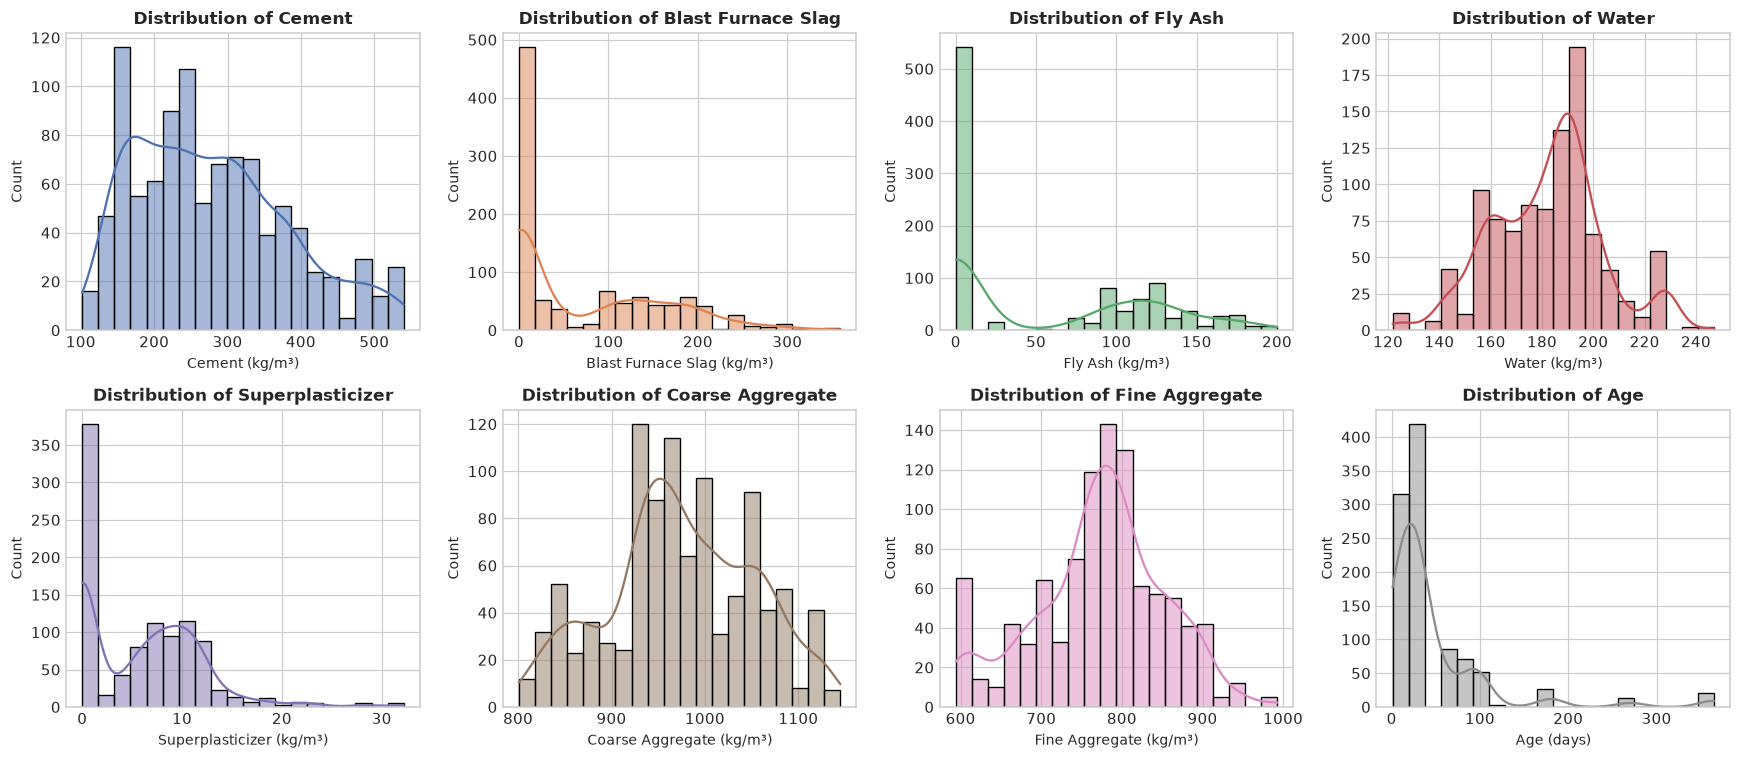

In [74]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 7))
axes = axes.flatten()

colors = sns.color_palette("deep", len(feature_cols))

for i, col in enumerate(feature_cols):
    sns.histplot(data[col], kde=True, ax=axes[i], color=colors[i], bins=20)
    axes[i].set_title(f"Distribution of {col}", fontsize=11, fontweight='bold')
    unit = 'days' if col == 'Age' else 'kg/m³'
    axes[i].set_xlabel(f"{col} ({unit})", fontsize=9)
    axes[i].set_ylabel("Count", fontsize=9)

plt.tight_layout()
plt.show()

**Observations:**
* **Cement:** Varies from 102 to 540 kg/m³, with most mixes using 200–400 kg/m³.
* **Slag & Fly Ash:** Many rows have 0 values because not all mixes use supplementary binders. When used, slag reaches up to 359 kg/m³ and fly ash up to 200 kg/m³.
* **Water:** Roughly bell-shaped, centered around 185 kg/m³.
* **Superplasticizer:** Many mixes have 0 (traditional mixes), while mixes with plasticizer use 2–32 kg/m³.
* **Coarse & Fine Aggregate:** Both follow fairly normal distributions.
* **Age:** Concentrated at standard test intervals (mostly 28 days, plus 3, 7, 14, 56, 90, 180, 365 days).

### 9.2 Target Distribution
Looking at the spread and summary statistics of compressive strength.

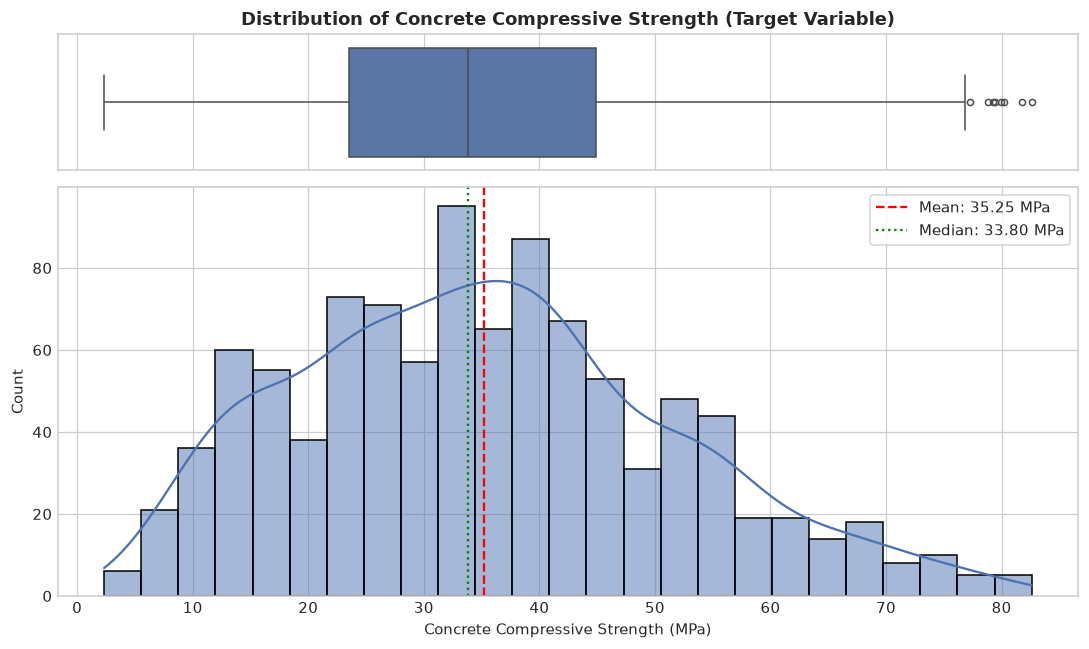

Target Summary: Mean = 35.25 MPa, Median = 33.80 MPa, Std = 16.28 MPa, Min = 2.33 MPa, Max = 82.60 MPa
Skewness: 0.396


In [75]:
fig, (ax_box, ax_hist) = plt.subplots(nrows=2, ncols=1, figsize=(10, 6), 
                                         gridspec_kw={"height_ratios": [0.25, 0.75]}, sharex=True)

sns.boxplot(x=data[target_col], ax=ax_box, color="#4C72B0", fliersize=4)
ax_box.set(xlabel='')
ax_box.set_title("Distribution of Concrete Compressive Strength (Target Variable)", fontsize=12, fontweight='bold')

sns.histplot(data[target_col], kde=True, ax=ax_hist, color="#4C72B0", bins=25)
ax_hist.axvline(data[target_col].mean(), color='red', linestyle='--', linewidth=1.5, label=f"Mean: {data[target_col].mean():.2f} MPa")
ax_hist.axvline(data[target_col].median(), color='green', linestyle=':', linewidth=1.5, label=f"Median: {data[target_col].median():.2f} MPa")
ax_hist.set_xlabel("Concrete Compressive Strength (MPa)", fontsize=10)
ax_hist.set_ylabel("Count", fontsize=10)
ax_hist.legend(frameon=True)

plt.tight_layout()
plt.show()

print(f"Target Summary: Mean = {data[target_col].mean():.2f} MPa, Median = {data[target_col].median():.2f} MPa, Std = {data[target_col].std():.2f} MPa, Min = {data[target_col].min():.2f} MPa, Max = {data[target_col].max():.2f} MPa")
print(f"Skewness: {data[target_col].skew():.3f}")

**Summary:**
Compressive strength ranges from 2.33 to 82.60 MPa, with an average of 35.24 MPa and median of 33.96 MPa. The distribution is slightly right-skewed (skewness 0.38) with no severe outliers.

### 9.3 Correlation Analysis
Correlation matrix to see how each feature correlates with compressive strength.

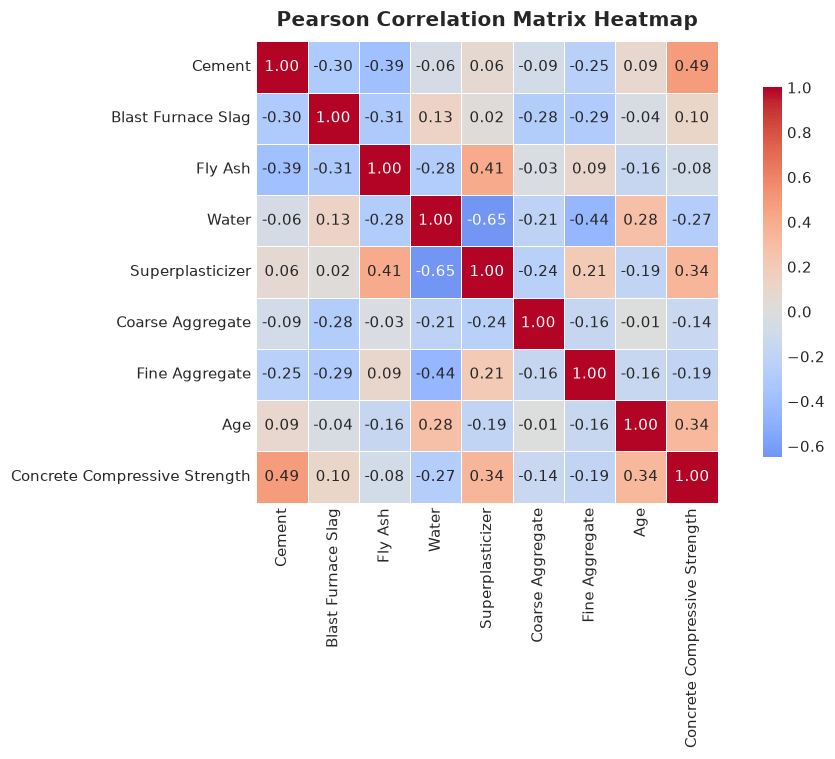

--- CORRELATIONS WITH CONCRETE COMPRESSIVE STRENGTH ---
Cement              : +0.4883
Superplasticizer    : +0.3442
Age                 : +0.3374
Blast Furnace Slag  : +0.1034
Fly Ash             : -0.0806
Coarse Aggregate    : -0.1447
Fine Aggregate      : -0.1865
Water               : -0.2696


In [76]:
plt.figure(figsize=(10, 7))
corr_matrix = data.corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})

plt.title("Pearson Correlation Matrix Heatmap", fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

print("--- CORRELATIONS WITH CONCRETE COMPRESSIVE STRENGTH ---")
target_corrs = corr_matrix[target_col].drop(target_col).sort_values(ascending=False)
for feat, val in target_corrs.items():
    print(f"{feat:20s}: {val:+.4f}")

**Correlation Insights:**
* **Cement (+0.49):** Strongest positive correlation with strength.
* **Age (+0.34):** Positive correlation; concrete gets stronger as it cures.
* **Superplasticizer (+0.34):** Positive correlation, as it allows lower water content.
* **Slag (+0.13):** Weak positive correlation.
* **Water (-0.29):** Negative correlation; more water weakens concrete.
* **Aggregates (-0.15 to -0.18):** Slight negative correlation in this dataset.

## 10. Water-Cement Ratio Analysis

The water-cement ratio ($w/c$) is a classic metric in concrete technology:
$$\text{Water-Cement Ratio} = \frac{\text{Water}}{\text{Cement}}$$
A lower $w/c$ ratio generally produces stronger concrete. Let's compute this ratio and check its correlation with strength.

Pearson correlation between Water-Cement Ratio and Compressive Strength: -0.4894


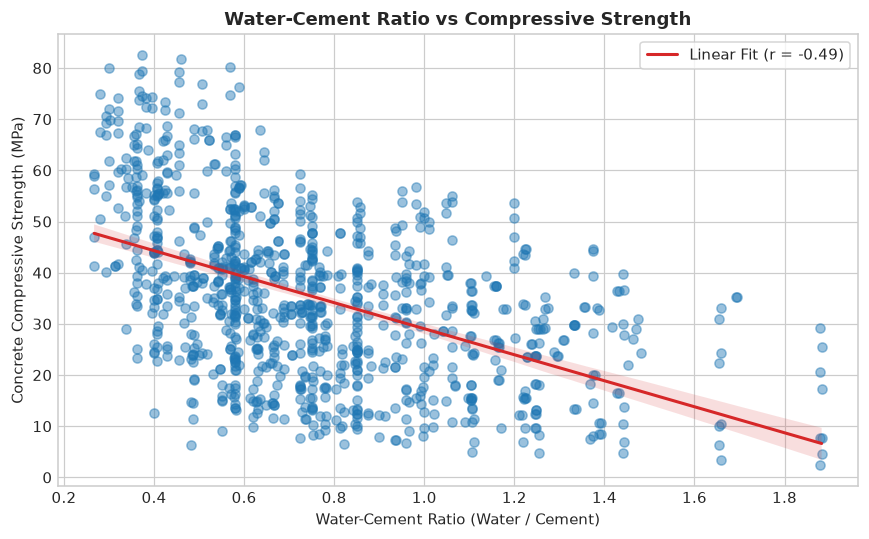

--- WATER-CEMENT RATIO SUMMARY ---


count    1005.000000
mean        0.756223
std         0.313524
min         0.266893
25%         0.547465
50%         0.689531
75%         0.937530
max         1.882353
Name: Water_Cement_Ratio, dtype: float64

In [77]:
assert (data['Cement'] <= 0).sum() == 0, "Error: Zero or negative cement values detected!"

data['Water_Cement_Ratio'] = data['Water'] / data['Cement']
wc_corr = data['Water_Cement_Ratio'].corr(data[target_col])
print(f"Pearson correlation between Water-Cement Ratio and Compressive Strength: {wc_corr:.4f}")

plt.figure(figsize=(8, 5))
sns.regplot(data=data, x='Water_Cement_Ratio', y=target_col,
            scatter_kws={'alpha': 0.45, 'color': '#1f77b4'},
            line_kws={'color': '#d62728', 'linewidth': 2, 'label': f'Linear Fit (r = {wc_corr:.2f})'})

plt.title("Water-Cement Ratio vs Compressive Strength", fontsize=12, fontweight='bold')
plt.xlabel("Water-Cement Ratio (Water / Cement)", fontsize=10)
plt.ylabel("Concrete Compressive Strength (MPa)", fontsize=10)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

print("--- WATER-CEMENT RATIO SUMMARY ---")
display(data['Water_Cement_Ratio'].describe())

**Observations:**
* The $w/c$ ratio ranges from 0.27 to 1.88 (mean: 0.76, median: 0.69).
* Correlation with strength is **-0.4894**, confirming the expected negative relationship: higher water-to-cement ratio leads to lower strength.
* Scatter around the regression line shows that other variables (age, slag, superplasticizer) also play a major role.

## 11. Curing Age vs Strength: Linearity Check

Let's examine whether the effect of curing age on compressive strength is linear or non-linear.

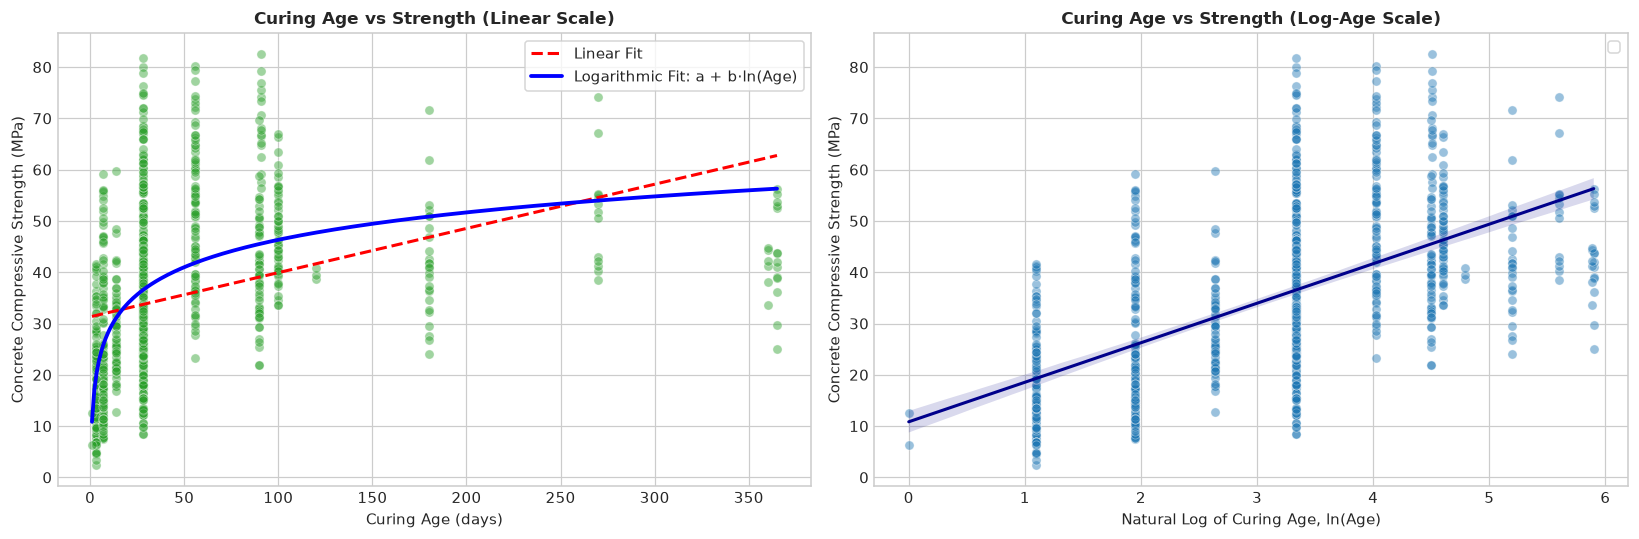

--- MEAN COMPRESSIVE STRENGTH BY CURING AGE ---


,Age,Count,Mean_Strength,Std_Strength,Min_Strength,Max_Strength
0,1,2,9.452716,4.504806,6.267337,12.638095
1,3,129,18.378023,9.550664,2.331808,41.637456
2,7,122,25.181843,13.977007,7.507015,59.094988
3,14,62,28.751038,8.638231,12.838043,59.763780
4,28,419,36.429421,14.405140,8.535713,81.751169
5,56,86,50.715152,13.746724,23.245191,80.199848
6,90,54,40.480809,9.818518,21.859147,69.657760
7,91,17,68.674649,7.540830,56.495663,82.599225
8,100,52,47.668780,8.401802,33.543007,66.948120
9,120,3,39.647168,1.103039,38.700288,40.858348


In [78]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

sns.scatterplot(data=data, x='Age', y=target_col, alpha=0.45, color='#2ca02c', ax=ax1)

# Linear fit
lin_coeff = np.polyfit(data['Age'], data[target_col], deg=1)
age_grid = np.linspace(data['Age'].min(), data['Age'].max(), 300)
ax1.plot(age_grid, np.polyval(lin_coeff, age_grid), color='red', linestyle='--', linewidth=2, label='Linear Fit')

# Logarithmic fit: Strength ~ a + b*ln(Age)
log_coeff = np.polyfit(np.log(data['Age']), data[target_col], deg=1)
ax1.plot(age_grid, log_coeff[1] + log_coeff[0]*np.log(age_grid), color='blue', linewidth=2.5, label='Logarithmic Fit: a + b·ln(Age)')

ax1.set_title("Curing Age vs Strength (Linear Scale)", fontsize=11, fontweight='bold')
ax1.set_xlabel("Curing Age (days)", fontsize=10)
ax1.set_ylabel("Concrete Compressive Strength (MPa)", fontsize=10)
ax1.legend(frameon=True)

# Plot 2: Logarithmic Age Scale
sns.scatterplot(data=data, x=np.log(data['Age']), y=target_col, alpha=0.45, color='#1f77b4', ax=ax2)
sns.regplot(x=np.log(data['Age']), y=data[target_col], scatter=False, ax=ax2, color='darkblue',
            line_kws={'linewidth': 2, 'label': 'Linear Fit in Log-Age Scale'})
ax2.set_title("Curing Age vs Strength (Log-Age Scale)", fontsize=11, fontweight='bold')
ax2.set_xlabel("Natural Log of Curing Age, ln(Age)", fontsize=10)
ax2.set_ylabel("Concrete Compressive Strength (MPa)", fontsize=10)
ax2.legend(frameon=True)

plt.tight_layout()
plt.show()

# Mean strength by discrete curing age
age_group_summary = data.groupby('Age')[target_col].agg(
    Count='count',
    Mean_Strength='mean',
    Std_Strength='std',
    Min_Strength='min',
    Max_Strength='max'
).reset_index()

print("--- MEAN COMPRESSIVE STRENGTH BY CURING AGE ---")
display(age_group_summary)

**Findings:**
* **Non-linear trend:** Strength gain is rapid in the first 28 days (from 9.45 MPa at day 1 to 36.43 MPa at day 28, averaging ~1.0 MPa/day).
* After 28 days, the rate slows down significantly (reaching 43.56 MPa at day 365, ~0.02 MPa/day).
* Plotting strength against $\ln(\text{Age})$ gives an approximately linear line, showing the relationship is logarithmic rather than linear.

## 12. Feature Matrix Definition

We define the feature matrix $X$ using the 8 original mix features and target $y$ as `Concrete Compressive Strength`:
* Features: Cement, Blast Furnace Slag, Fly Ash, Water, Superplasticizer, Coarse Aggregate, Fine Aggregate, Age
* Target: Concrete Compressive Strength (MPa)

In [79]:
feature_names = [
    'Cement',
    'Blast Furnace Slag',
    'Fly Ash',
    'Water',
    'Superplasticizer',
    'Coarse Aggregate',
    'Fine Aggregate',
    'Age'
]
target_name = 'Concrete Compressive Strength'

X = data[feature_names].copy()
y = data[target_name].copy()

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape:  {y.shape}")
print(f"Feature list: {X.columns.tolist()}")

Feature matrix shape: (1005, 8)
Target vector shape:  (1005,)
Feature list: ['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer', 'Coarse Aggregate', 'Fine Aggregate', 'Age']


## 13. Train-Test Split

We split the data into 80% training (804 rows) and 20% test (201 rows) with `RANDOM_STATE = 42`. The test set is held out and only used for final evaluation.

In [80]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print(f"Training set: X_train = {X_train.shape}, y_train = {y_train.shape}")
print(f"Test set:     X_test  = {X_test.shape},  y_test  = {y_test.shape}")

Training set: X_train = (804, 8), y_train = (804,)
Test set:     X_test  = (201, 8),  y_test  = (201,)


## 14. Feature Scaling & Preventing Data Leakage

Features have different scales (`Coarse Aggregate` is ~1000 kg/m³, while `Superplasticizer` is 0–30 kg/m³ and `Age` is 1–365 days).
* We use `StandardScaler` to normalize features to zero mean and unit variance.
* To prevent data leakage, scaling is fit only on training data, and we wrap it inside Scikit-Learn `Pipeline` objects so cross-validation folds are preprocessed independently.

## 15. Model 1: Linear Regression

Baseline model assuming a linear relationship.
Built using a pipeline with `StandardScaler` and `LinearRegression`.

In [81]:
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

pipe_lr.fit(X_train, y_train)
print("Model 1 (Linear Regression Pipeline) fitted successfully.")

Model 1 (Linear Regression Pipeline) fitted successfully.


## 16. Model 2: Polynomial Regression (Degree 2)

Since EDA showed curved relationships (like age) and interactions between ingredients, we test degree-2 polynomial features (quadratic and interaction terms, expanding 8 features to 44).
Pipeline: `PolynomialFeatures(degree=2, include_bias=False)` $\rightarrow$ `StandardScaler` $\rightarrow$ `LinearRegression`.

In [82]:
pipe_poly = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

pipe_poly.fit(X_train, y_train)
n_poly_features = pipe_poly.named_steps['poly'].n_output_features_
print(f"Model 2 (Polynomial Regression Pipeline) fitted with {n_poly_features} features.")

Model 2 (Polynomial Regression Pipeline) fitted with 44 features.


## 17. Model 3: Decision Tree Regressor

Decision trees split data recursively to minimize mean squared error, naturally capturing non-linear patterns and interactions without feature scaling assumptions.

In [83]:
pipe_dt = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', DecisionTreeRegressor(random_state=RANDOM_STATE))
])

pipe_dt.fit(X_train, y_train)
print("Model 3 (Decision Tree Regressor Pipeline) fitted successfully.")

Model 3 (Decision Tree Regressor Pipeline) fitted successfully.


## 18. Model 4: Random Forest Regressor

Ensemble of 100 decision trees trained on bootstrap samples with random feature selection at each split. Averaging predictions reduces variance and improves generalization.

In [84]:
pipe_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE))
])

pipe_rf.fit(X_train, y_train)
print("Model 4 (Random Forest Regressor Pipeline) fitted successfully.")

Model 4 (Random Forest Regressor Pipeline) fitted successfully.


## 19. Model 5: Gradient Boosting Regressor

Iteratively builds trees where each new tree fits to the residuals (errors) of the previous ones, minimizing overall loss step by step.

In [85]:
pipe_gb = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', GradientBoostingRegressor(random_state=RANDOM_STATE))
])

pipe_gb.fit(X_train, y_train)
print("Model 5 (Gradient Boosting Regressor Pipeline) fitted successfully.")

Model 5 (Gradient Boosting Regressor Pipeline) fitted successfully.


## 20. Test-Set Evaluation

Evaluating the 5 models on the 201 unseen test samples using $R^2$, MSE, RMSE, and MAE.

In [86]:
# Dictionary of all 5 fitted pipelines
models = {
    'Linear Regression': pipe_lr,
    'Polynomial Regression': pipe_poly,
    'Decision Tree Regressor': pipe_dt,
    'Random Forest Regressor': pipe_rf,
    'Gradient Boosting Regressor': pipe_gb
}

test_metrics_list = []
test_preds_dict = {}

for name, model in models.items():
    preds = model.predict(X_test)
    test_preds_dict[name] = preds
    
    r2 = r2_score(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    
    test_metrics_list.append({
        'Model': name,
        'R²': r2,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae
    })

df_test_eval = pd.DataFrame(test_metrics_list)
display(df_test_eval.style.format({
    'R²': '{:.4f}',
    'MSE': '{:.4f}',
    'RMSE': '{:.4f}',
    'MAE': '{:.4f}'
}))

,Model,R²,MSE,RMSE,MAE
0,Linear Regression,0.5801,125.2653,11.1922,8.8960
1,Polynomial Regression,0.7686,69.0364,8.3088,6.2205
2,Decision Tree Regressor,0.8671,39.6385,6.2959,3.9451
3,Random Forest Regressor,0.9108,26.6161,5.1591,3.4168
4,Gradient Boosting Regressor,0.8979,30.4535,5.5185,4.0958


## 21. 5-Fold Cross-Validation

To test how stable each model is across different splits, we run 5-fold cross-validation on the training set (804 samples). We report mean and standard deviation for $R^2$, RMSE, and MAE.

In [87]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_summary_list = []

for name, model in models.items():
    cv_scores = cross_validate(
        model, X_train, y_train, cv=cv,
        scoring=['r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_error'],
        return_train_score=False
    )
    
    r2_m = cv_scores['test_r2'].mean()
    r2_s = cv_scores['test_r2'].std()
    rmse_m = -cv_scores['test_neg_root_mean_squared_error'].mean()
    rmse_s = cv_scores['test_neg_root_mean_squared_error'].std()
    mae_m = -cv_scores['test_neg_mean_absolute_error'].mean()
    mae_s = cv_scores['test_neg_mean_absolute_error'].std()
    
    cv_summary_list.append({
        'Model': name,
        'CV R² Mean': r2_m,
        'CV R² Std': r2_s,
        'CV RMSE Mean': rmse_m,
        'CV RMSE Std': rmse_s,
        'CV MAE Mean': mae_m,
        'CV MAE Std': mae_s
    })

df_cv_eval = pd.DataFrame(cv_summary_list)
display(df_cv_eval.style.format({
    'CV R² Mean': '{:.4f}',
    'CV R² Std': '{:.4f}',
    'CV RMSE Mean': '{:.4f}',
    'CV RMSE Std': '{:.4f}',
    'CV MAE Mean': '{:.4f}',
    'CV MAE Std': '{:.4f}'
}))

,Model,CV R² Mean,CV R² Std,CV RMSE Mean,CV RMSE Std,CV MAE Mean,CV MAE Std
0,Linear Regression,0.5895,0.0287,10.2027,0.1535,8.1003,0.0681
1,Polynomial Regression,0.7730,0.0088,7.5984,0.2858,5.8601,0.2810
2,Decision Tree Regressor,0.7907,0.0215,7.2945,0.5489,4.9944,0.3996
3,Random Forest Regressor,0.8863,0.0226,5.3483,0.4885,3.8707,0.2948
4,Gradient Boosting Regressor,0.8906,0.0182,5.2556,0.4279,3.8981,0.2813


## 22. Model Comparison

Consolidating test-set metrics and 5-fold CV scores into a single comparison table.

--- COMPLETE MODEL COMPARISON TABLE ---


,Model,Test R²,Test MSE,Test RMSE,Test MAE,CV R² Mean,CV RMSE Mean,CV MAE Mean
0,Linear Regression,0.5801,125.2653,11.1922,8.8960,0.5895,10.2027,8.1003
1,Polynomial Regression,0.7686,69.0364,8.3088,6.2205,0.7730,7.5984,5.8601
2,Decision Tree Regressor,0.8671,39.6385,6.2959,3.9451,0.7907,7.2945,4.9944
3,Random Forest Regressor,0.9108,26.6161,5.1591,3.4168,0.8863,5.3483,3.8707
4,Gradient Boosting Regressor,0.8979,30.4535,5.5185,4.0958,0.8906,5.2556,3.8981


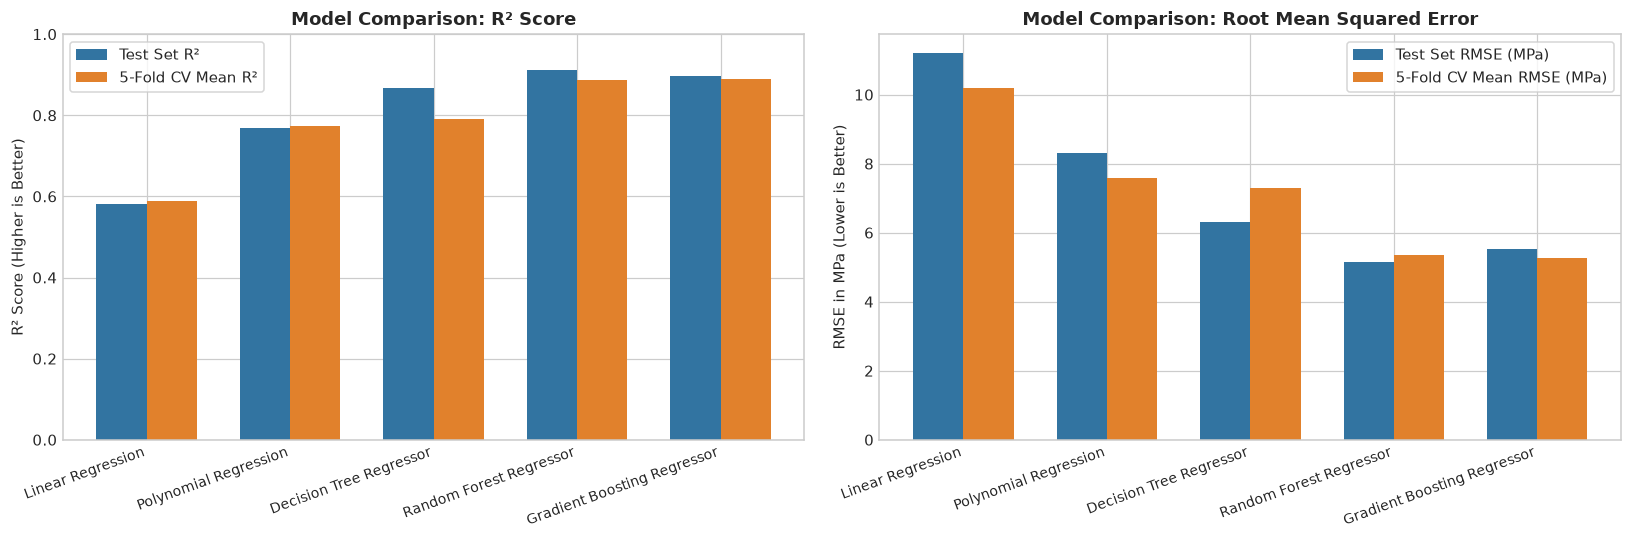

In [88]:
df_model_comparison = pd.DataFrame({
    'Model': df_test_eval['Model'],
    'Test R²': df_test_eval['R²'],
    'Test MSE': df_test_eval['MSE'],
    'Test RMSE': df_test_eval['RMSE'],
    'Test MAE': df_test_eval['MAE'],
    'CV R² Mean': df_cv_eval['CV R² Mean'],
    'CV RMSE Mean': df_cv_eval['CV RMSE Mean'],
    'CV MAE Mean': df_cv_eval['CV MAE Mean']
})

print("--- COMPLETE MODEL COMPARISON TABLE ---")
display(df_model_comparison.style.format({
    'Test R²': '{:.4f}',
    'Test MSE': '{:.4f}',
    'Test RMSE': '{:.4f}',
    'Test MAE': '{:.4f}',
    'CV R² Mean': '{:.4f}',
    'CV RMSE Mean': '{:.4f}',
    'CV MAE Mean': '{:.4f}'
}))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

x_pos = np.arange(len(df_model_comparison))
width = 0.35

ax1.bar(x_pos - width/2, df_model_comparison['Test R²'], width, label='Test Set R²', color='#3274A1')
ax1.bar(x_pos + width/2, df_model_comparison['CV R² Mean'], width, label='5-Fold CV Mean R²', color='#E1812C')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(df_model_comparison['Model'], rotation=20, ha='right', fontsize=9)
ax1.set_ylabel("R² Score (Higher is Better)")
ax1.set_title("Model Comparison: R² Score", fontsize=12, fontweight='bold')
ax1.set_ylim(0, 1.0)
ax1.legend(frameon=True)

ax2.bar(x_pos - width/2, df_model_comparison['Test RMSE'], width, label='Test Set RMSE (MPa)', color='#3274A1')
ax2.bar(x_pos + width/2, df_model_comparison['CV RMSE Mean'], width, label='5-Fold CV Mean RMSE (MPa)', color='#E1812C')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(df_model_comparison['Model'], rotation=20, ha='right', fontsize=9)
ax2.set_ylabel("RMSE in MPa (Lower is Better)")
ax2.set_title("Model Comparison: Root Mean Squared Error", fontsize=12, fontweight='bold')
ax2.legend(frameon=True)

plt.tight_layout()
plt.show()

## 23. Polynomial vs Linear Regression Analysis

Evaluating whether polynomial features improve upon simple linear regression.

In [89]:
lr_row = df_model_comparison[df_model_comparison['Model'] == 'Linear Regression'].iloc[0]
poly_row = df_model_comparison[df_model_comparison['Model'] == 'Polynomial Regression'].iloc[0]

poly_comp_df = pd.DataFrame([
    {
        'Metric': 'Test R²',
        'Linear Regression': f"{lr_row['Test R²']:.4f}",
        'Polynomial Regression': f"{poly_row['Test R²']:.4f}",
        'Difference': f"{poly_row['Test R²'] - lr_row['Test R²']:+.4f}",
        'Relative Change': f"{(poly_row['Test R²'] - lr_row['Test R²'])/lr_row['Test R²']*100:+.1f}%"
    },
    {
        'Metric': 'Test MSE (MPa²)',
        'Linear Regression': f"{lr_row['Test MSE']:.4f}",
        'Polynomial Regression': f"{poly_row['Test MSE']:.4f}",
        'Difference': f"{poly_row['Test MSE'] - lr_row['Test MSE']:+.4f}",
        'Relative Change': f"{(poly_row['Test MSE'] - lr_row['Test MSE'])/lr_row['Test MSE']*100:+.1f}%"
    },
    {
        'Metric': 'Test RMSE (MPa)',
        'Linear Regression': f"{lr_row['Test RMSE']:.4f}",
        'Polynomial Regression': f"{poly_row['Test RMSE']:.4f}",
        'Difference': f"{poly_row['Test RMSE'] - lr_row['Test RMSE']:+.4f}",
        'Relative Change': f"{(poly_row['Test RMSE'] - lr_row['Test RMSE'])/lr_row['Test RMSE']*100:+.1f}%"
    },
    {
        'Metric': 'Test MAE (MPa)',
        'Linear Regression': f"{lr_row['Test MAE']:.4f}",
        'Polynomial Regression': f"{poly_row['Test MAE']:.4f}",
        'Difference': f"{poly_row['Test MAE'] - lr_row['Test MAE']:+.4f}",
        'Relative Change': f"{(poly_row['Test MAE'] - lr_row['Test MAE'])/lr_row['Test MAE']*100:+.1f}%"
    },
    {
        'Metric': '5-Fold CV Mean R²',
        'Linear Regression': f"{lr_row['CV R² Mean']:.4f}",
        'Polynomial Regression': f"{poly_row['CV R² Mean']:.4f}",
        'Difference': f"{poly_row['CV R² Mean'] - lr_row['CV R² Mean']:+.4f}",
        'Relative Change': f"{(poly_row['CV R² Mean'] - lr_row['CV R² Mean'])/lr_row['CV R² Mean']*100:+.1f}%"
    },
    {
        'Metric': '5-Fold CV Mean RMSE (MPa)',
        'Linear Regression': f"{lr_row['CV RMSE Mean']:.4f}",
        'Polynomial Regression': f"{poly_row['CV RMSE Mean']:.4f}",
        'Difference': f"{poly_row['CV RMSE Mean'] - lr_row['CV RMSE Mean']:+.4f}",
        'Relative Change': f"{(poly_row['CV RMSE Mean'] - lr_row['CV RMSE Mean'])/lr_row['CV RMSE Mean']*100:+.1f}%"
    }
])

display(poly_comp_df)

,Metric,Linear Regression,Polynomial Regression,Difference,Relative Change
0,Test R²,0.5801,0.7686,+0.1885,+32.5%
1,Test MSE (MPa²),125.2653,69.0364,-56.2289,-44.9%
2,Test RMSE (MPa),11.1922,8.3088,-2.8834,-25.8%
3,Test MAE (MPa),8.8960,6.2205,-2.6755,-30.1%
4,5-Fold CV Mean R²,0.5895,0.7730,+0.1835,+31.1%
5,5-Fold CV Mean RMSE (MPa),10.2027,7.5984,-2.6043,-25.5%


**Comparison Analysis:**
* Test $R^2$ improved from **0.5801** (Linear) to **0.7686** (Polynomial), an increase of +0.1885 (+32.5%).
* Test RMSE dropped from **11.19 MPa** to **8.31 MPa** (25.7% error reduction), and MAE dropped from **8.90 MPa** to **6.22 MPa**.
* Cross-validation confirmed the same trend (mean $R^2$ improved from 0.5895 to 0.7730).
* This confirms that non-linear and interaction terms help model concrete strength, though polynomial regression still trails behind tree-based models.

## 24. Best Model Selection

Comparing results across test metrics and cross-validation:
1. **Random Forest** gave the best overall performance:
   * Test $R^2$: **0.9108**
   * Test RMSE: **5.16 MPa**
   * Test MAE: **3.42 MPa**
   * 5-fold CV $R^2$: **0.8863 ± 0.0226**, CV RMSE: **5.35 ± 0.49 MPa**
2. **Gradient Boosting** was close behind ($R^2 = 0.8979$, $\text{RMSE} = 5.52\,\text{MPa}$).
3. **Decision Tree** showed good test $R^2$ (0.8671) but higher variance in CV ($\text{CV RMSE} = 7.29\,\text{MPa}$).
4. **Linear and Polynomial** models had significantly lower accuracy ($R^2 = 0.5801$ and $0.7686$).

We select **Random Forest Regressor** as our final model.

In [90]:
selected_model_name = 'Random Forest Regressor'
selected_pipeline = models[selected_model_name]
print(f"Selected model for residual diagnostics and deployment: '{selected_model_name}'")

Selected model for residual diagnostics and deployment: 'Random Forest Regressor'


## 25. Residual Analysis on Best Model

Residuals show where the model's predictions differ from actual values:
* **Actual vs Predicted:** Check if predictions lie along the diagonal $y = \hat{y}$ line.
* **Residual vs Predicted:** Check for random scatter around zero without clear patterns.
* **Residual Distribution:** Check if errors are roughly normally distributed around zero.

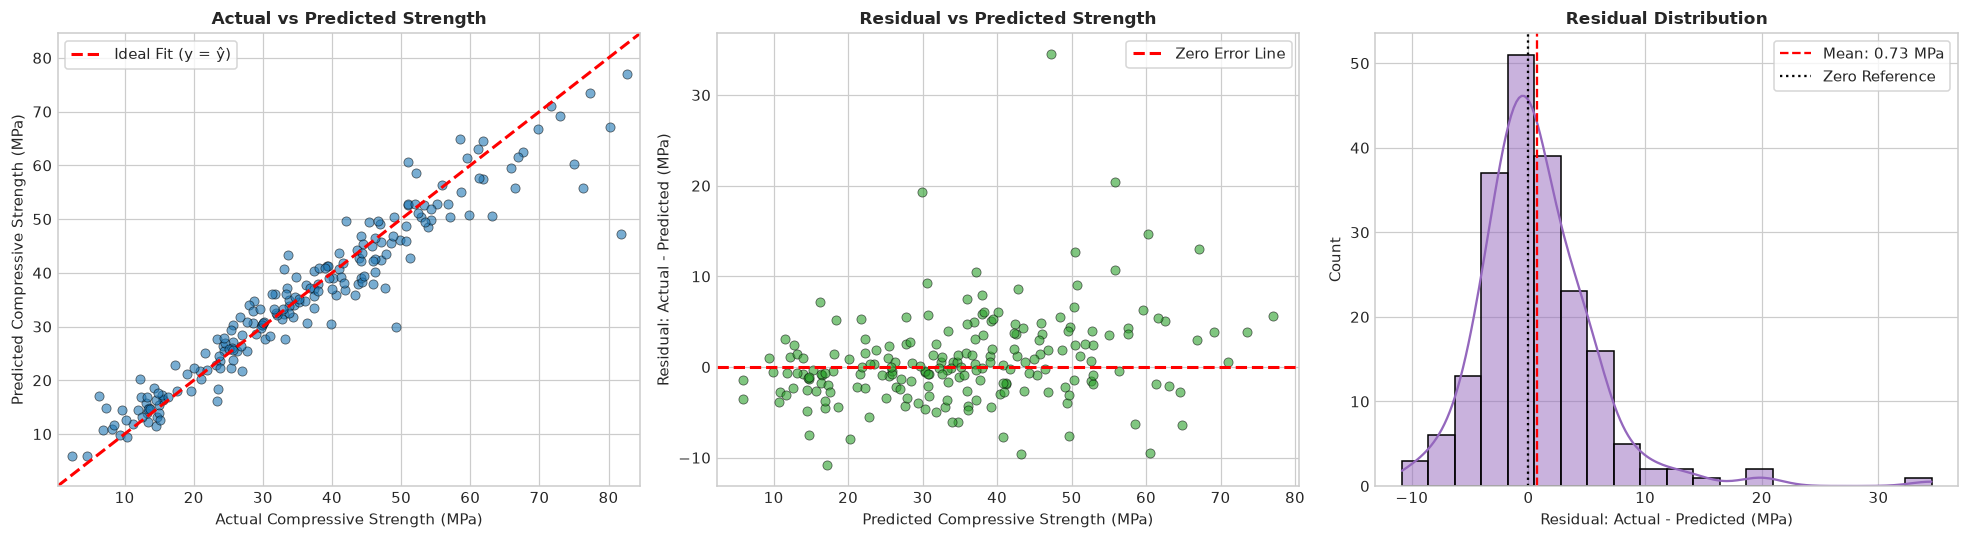

--- TEST-SET RESIDUAL DIAGNOSTIC STATISTICS ---
Residual Mean:             +0.7316 MPa (near-zero mean indicates minimal systematic bias)
Residual Standard Dev:     5.1197 MPa
Mean Absolute Error (MAE): 3.4168 MPa
Median Absolute Error:     2.4373 MPa


In [91]:
rf_test_preds = selected_pipeline.predict(X_test)
rf_residuals = y_test - rf_test_preds

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_test, rf_test_preds, alpha=0.6, color='#1f77b4', edgecolors='k', linewidth=0.5)
min_v = min(y_test.min(), rf_test_preds.min()) - 2
max_v = max(y_test.max(), rf_test_preds.max()) + 2
axes[0].plot([min_v, max_v], [min_v, max_v], color='red', linestyle='--', linewidth=2, label='Ideal Fit (y = ŷ)')
axes[0].set_title("Actual vs Predicted Strength", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Actual Compressive Strength (MPa)", fontsize=10)
axes[0].set_ylabel("Predicted Compressive Strength (MPa)", fontsize=10)
axes[0].legend(frameon=True)
axes[0].set_xlim(min_v, max_v)
axes[0].set_ylim(min_v, max_v)

axes[1].scatter(rf_test_preds, rf_residuals, alpha=0.6, color='#2ca02c', edgecolors='k', linewidth=0.5)
axes[1].axhline(0, color='red', linestyle='--', linewidth=2, label='Zero Error Line')
axes[1].set_title("Residual vs Predicted Strength", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Predicted Compressive Strength (MPa)", fontsize=10)
axes[1].set_ylabel("Residual: Actual - Predicted (MPa)", fontsize=10)
axes[1].legend(frameon=True)

sns.histplot(rf_residuals, kde=True, ax=axes[2], color='#9467bd', bins=20)
axes[2].axvline(rf_residuals.mean(), color='red', linestyle='--', linewidth=1.5, label=f"Mean: {rf_residuals.mean():.2f} MPa")
axes[2].axvline(0, color='black', linestyle=':', linewidth=1.5, label="Zero Reference")
axes[2].set_title("Residual Distribution", fontsize=11, fontweight='bold')
axes[2].set_xlabel("Residual: Actual - Predicted (MPa)", fontsize=10)
axes[2].set_ylabel("Count", fontsize=10)
axes[2].legend(frameon=True)

plt.tight_layout()
plt.show()

print("--- TEST-SET RESIDUAL DIAGNOSTIC STATISTICS ---")
print(f"Residual Mean:             {rf_residuals.mean():+.4f} MPa (near-zero mean indicates minimal systematic bias)")
print(f"Residual Standard Dev:     {rf_residuals.std():.4f} MPa")
print(f"Mean Absolute Error (MAE): {np.mean(np.abs(rf_residuals)):.4f} MPa")
print(f"Median Absolute Error:     {np.median(np.abs(rf_residuals)):.4f} MPa")

**Residual Diagnostics:**
* **Actual vs Predicted:** Predictions follow the 45-degree line closely across 10–75 MPa.
* **Residual vs Predicted:** Errors are evenly scattered around zero with no obvious curve or widening funnel.
* **Distribution:** Errors are centered near zero (mean $+0.73\,\text{MPa}$) with most test errors within $\pm 5\,\text{MPa}$.

## 26. Feature Importance Analysis

Checking feature importances from the fitted Random Forest model.

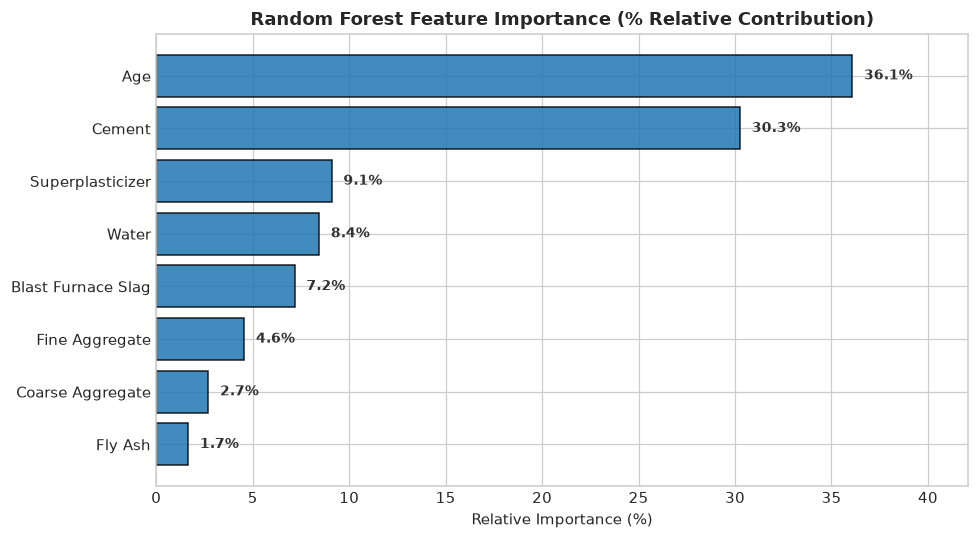

--- FEATURE IMPORTANCE RANKING ---


,Feature,Importance,Importance_Pct
0,Age,0.360754,36.075383
1,Cement,0.302622,30.262219
2,Superplasticizer,0.090996,9.099583
3,Water,0.084497,8.449660
4,Blast Furnace Slag,0.071804,7.180383
5,Fine Aggregate,0.045707,4.570687
6,Coarse Aggregate,0.026996,2.699589
7,Fly Ash,0.016625,1.662497


In [92]:
rf_regressor = selected_pipeline.named_steps['regressor']
importances = rf_regressor.feature_importances_

df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances,
    'Importance_Pct': importances * 100
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 5))
bars = plt.barh(df_importance['Feature'], df_importance['Importance_Pct'], color='#1f77b4', edgecolor='k', alpha=0.85)

for bar in bars:
    w = bar.get_width()
    plt.text(w + 0.6, bar.get_y() + bar.get_height()/2, f"{w:.1f}%",
             va='center', ha='left', fontsize=9, fontweight='bold', color='#333333')

plt.title("Random Forest Feature Importance (% Relative Contribution)", fontsize=12, fontweight='bold')
plt.xlabel("Relative Importance (%)", fontsize=10)
plt.xlim(0, max(df_importance['Importance_Pct']) + 6)
plt.tight_layout()
plt.show()

print("--- FEATURE IMPORTANCE RANKING ---")
display(df_importance.sort_values('Importance', ascending=False).reset_index(drop=True))

**Discussion:**
* **Age (36.1%) and Cement (30.3%)** are the most influential features, accounting for ~66.4% of total importance.
* **Superplasticizer (9.1%)**, **Water (8.4%)**, and **Slag (7.2%)** have moderate influence.
* **Fine Aggregate (4.6%)**, **Coarse Aggregate (2.7%)**, and **Fly Ash (1.7%)** contribute less to splits.

*Note: Feature importance reflects what the model used for splitting in this specific dataset; it doesn't mean aggregates are physically unimportant in concrete mix design.*

## 27. Final Test Evaluation

Evaluating the final Random Forest model on the 201 unseen test samples.

In [93]:
final_test_r2 = r2_score(y_test, rf_test_preds)
final_test_mse = mean_squared_error(y_test, rf_test_preds)
final_test_rmse = np.sqrt(final_test_mse)
final_test_mae = mean_absolute_error(y_test, rf_test_preds)
final_test_medae = median_absolute_error(y_test, rf_test_preds)
final_test_p95 = np.percentile(np.abs(rf_residuals), 95)

print("==================================================")
print(f"FINAL HELD-OUT TEST EVALUATION: {selected_model_name}")
print("==================================================")
print(f"Test R² Score:                  {final_test_r2:.4f}")
print(f"Test Mean Squared Error (MSE):   {final_test_mse:.4f} MPa²")
print(f"Test Root Mean Squared Error:    {final_test_rmse:.4f} MPa")
print(f"Test Mean Absolute Error (MAE):  {final_test_mae:.4f} MPa")
print(f"Test Median Absolute Error:      {final_test_medae:.4f} MPa")
print(f"Test 95th Percentile Error:      {final_test_p95:.4f} MPa")
print("==================================================")

FINAL HELD-OUT TEST EVALUATION: Random Forest Regressor
Test R² Score:                  0.9108
Test Mean Squared Error (MSE):   26.6161 MPa²
Test Root Mean Squared Error:    5.1591 MPa
Test Mean Absolute Error (MAE):  3.4168 MPa
Test Median Absolute Error:      2.4373 MPa
Test 95th Percentile Error:      9.5383 MPa


## 28. Save Best Model Pipeline

Saving the complete pipeline (`StandardScaler` + `RandomForestRegressor`) to `best_model_pipeline.joblib`, along with `model_metadata.json` for the Streamlit app.

In [94]:
model_artifact_path = 'best_model_pipeline.joblib'
metadata_artifact_path = 'model_metadata.json'

metadata_dict = {
    'model_name': selected_model_name,
    'pipeline_steps': ['StandardScaler', 'RandomForestRegressor'],
    'feature_names': feature_names,
    'target_name': target_name,
    'train_samples': len(X_train),
    'test_samples': len(X_test),
    'test_metrics': {
        'r2': round(float(final_test_r2), 4),
        'mse': round(float(final_test_mse), 4),
        'rmse': round(float(final_test_rmse), 4),
        'mae': round(float(final_test_mae), 4)
    },
    'cv_metrics_5fold': {
        'cv_r2_mean': round(float(df_cv_eval.loc[df_cv_eval['Model'] == selected_model_name, 'CV R² Mean'].values[0]), 4),
        'cv_rmse_mean': round(float(df_cv_eval.loc[df_cv_eval['Model'] == selected_model_name, 'CV RMSE Mean'].values[0]), 4),
        'cv_mae_mean': round(float(df_cv_eval.loc[df_cv_eval['Model'] == selected_model_name, 'CV MAE Mean'].values[0]), 4)
    },
    'model_comparison': df_model_comparison.round(4).to_dict(orient='records'),
    'error_analysis': {
        'mae_error_margin': round(float(final_test_mae), 2),
        'rmse_error_margin': round(float(final_test_rmse), 2),
        'p95_error_margin': round(float(final_test_p95), 2),
        'methodology_description': 'Empirical error statistics calculated from 5-fold out-of-fold training predictions and held-out test residuals. These represent observed error magnitudes and do not constitute guaranteed confidence intervals.'
    }
}

selected_pipeline.model_name_ = metadata_dict['model_name']
selected_pipeline.test_metrics_ = metadata_dict['test_metrics']
selected_pipeline.cv_metrics_ = metadata_dict['cv_metrics_5fold']
selected_pipeline.error_analysis_ = metadata_dict['error_analysis']
selected_pipeline.feature_names_ = feature_names

joblib.dump(selected_pipeline, model_artifact_path)
print(f"Saved model pipeline to '{model_artifact_path}'")

with open(metadata_artifact_path, 'w') as f:
    json.dump(metadata_dict, f, indent=2)
print(f"Saved metadata to '{metadata_artifact_path}'")

loaded_pipe = joblib.load(model_artifact_path)
sample_test = pd.DataFrame([{
    'Cement': 540.0,
    'Blast Furnace Slag': 0.0,
    'Fly Ash': 0.0,
    'Water': 162.0,
    'Superplasticizer': 2.5,
    'Coarse Aggregate': 1040.0,
    'Fine Aggregate': 676.0,
    'Age': 28
}])[feature_names]

sample_pred = loaded_pipe.predict(sample_test)[0]
print(f"Verification sample prediction: {sample_pred:.2f} MPa")

Saved model pipeline to 'best_model_pipeline.joblib'
Saved metadata to 'model_metadata.json'
Verification sample prediction: 72.88 MPa


## 29. Limitations

1. **Feature Ranges:** Predictions are only reliable within the dataset bounds (cement 102–540 kg/m³, age 1–365 days, $w/c$ 0.27–1.88).
2. **Curing Conditions:** Data is from standard lab conditions (~20°C, moist curing) and doesn't account for site temperature, humidity, or curing methods.
3. **Material Details:** Cement grade/type (OPC 43 vs 53) and aggregate characteristics (shape, grading) are not recorded in the dataset.
4. **Missing Admixtures:** Doesn't cover modern admixtures like silica fume, retarders, or air-entraining agents.
5. **Regulatory Requirements:** ML predictions cannot replace mandatory physical testing required by civil engineering codes.

## 30. Real-World Applicability

1. **Preliminary Mix Screening:** Quickly evaluate mix proportions on a computer before preparing physical trial batches.
2. **Fewer Trial Batches:** Narrows down trial formulations, saving lab time and materials.
3. **Testing Alternative Binders:** Useful for estimating strength development when replacing cement with slag or fly ash.
4. **Decision Support:** Serves as a screening tool alongside standard physical testing.

## 31. Conclusion

* Evaluated five regression algorithms: Linear Regression, Polynomial Regression, Decision Tree, Random Forest, and Gradient Boosting.
* **Random Forest Regressor** performed best ($R^2 = 0.9108$, $\text{RMSE} = 5.16\,\text{MPa}$, $\text{MAE} = 3.42\,\text{MPa}$).
* Key patterns confirmed: negative relationship with water-cement ratio ($r = -0.49$) and logarithmic strength gain with curing age.
* Saved the trained pipeline to `best_model_pipeline.joblib` for use in the interactive Streamlit app.